In [1]:
import sys
from IPython.display import display, Javascript

def restart_kernel():
    """Restart the Jupyter Notebook kernel to reflect changes in modules and packages."""
    display(Javascript("Jupyter.notebook.kernel.restart()"))
    print("Kernel is restarting...")

restart_kernel()

import numpy as np
import torch
import tensorly as tl
from tensorly.decomposition import parafac
import sparse
import pickle
import os
import numpy.random as rn
import scipy.stats as st
from tensorly.cp_tensor import CPTensor
import matplotlib.pyplot as plt

from own_implementation import BPTF as BPTF
import bptf

# Please run everything up to the first bptf fit
# Thereafter, run each following cell on their own

<IPython.core.display.Javascript object>

Kernel is restarting...


# Helper functions

In [2]:
def generate(shp=(30, 30, 20, 10), K=5, alpha=0.1, beta=0.1):
    """Generate a count tensor from the BPTF model.

    PARAMS:
    shp -- (tuple) shape of the generated count tensor
    K -- (int) number of latent components
    alpha -- (float) shape parameter of gamma prior over factors
    beta -- (float) rate parameter of gamma prior over factors

    RETURNS:
    Mu -- (np.ndarray) true Poisson rates
    Y -- (np.ndarray) generated count tensor
    """
    Theta_DK_M = [rn.gamma(alpha, 1./beta, size=(D, K)) for D in shp]
    Theta_DK_M = [torch.tensor(factor) for factor in Theta_DK_M]
    Mu = tl.cp_to_tensor(CPTensor((None, Theta_DK_M)))
    assert Mu.shape == shp
    Y = rn.poisson(Mu)
    return Mu, Y

# Load data

In [3]:
use_existing_data = True

# for the first bptf.fit:
# using seed 100 causes the assert delta >= 0 to trip
# but using seed 0 doesn't
# please swap between the 2 seeds to get the 2 different types of assertion errors in the other cells
rn.seed(100)
device = 'cuda'
num_months = 12

if use_existing_data:
    assert os.path.exists('sptensor.pkl'), 'No such file.'
    with open('sptensor.pkl', 'rb') as f:
        data = pickle.load(f)
    data = data[:, :, :, :num_months, :]
    data = torch.tensor(data.todense(), dtype=torch.float64, device=device)
else:
    data = generate(shp=(200, 200, 20, num_months, 3), K=10)[1]
    data = torch.tensor(data, dtype=torch.float64, device=device)

# Building mask (base example)

In [4]:
mask = np.ones(data.shape)
# april of GDELT is set to missing
mask[:, :, :, 3, 1] = 0

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 0
mask = torch.tensor(mask.astype(np.int64), dtype=torch.float64, device=device)

# Fit model

Change is small enough, early break:  42%|████▏     | 211/500 [07:15<09:56,  2.07s/it]                         


Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-2777075742.728431, 5173117.194390231, 5315980.280997981, 5659448.2752028275, 6692848.916802176, 7990530.6146523915, 9075490.721082099, 9882070.216433499, 10384563.031170947, 10687764.53036105, 10901250.966526223, 11065653.808318317, 11196265.484640341, 11308922.787051618, 11410950.67525758, 11499290.759260653, 11572503.655984992, 11631267.112153418, 11677664.349015355, 11716049.222492822, 11750752.470242526, 11784106.34732377, 11814981.224142095, 11841095.386276972, 11862358.1477209, 11879329.316177674, 11893358.476007108, 11905756.089614306, 11917045.279385783, 11927365.4514252, 11936506.6604958, 11944476.991633223, 11951574.304031357, 11958091.40510366, 11964190.778855395, 11969861.000594823, 11975139.85070651, 11980126.961159393, 11984889.5858806, 11989485.968012342, 11993918.48510523, 11998213.467762824, 12002399.31322356, 12006536.76852037, 12010621.845358066, 12014732.458135627, 12018

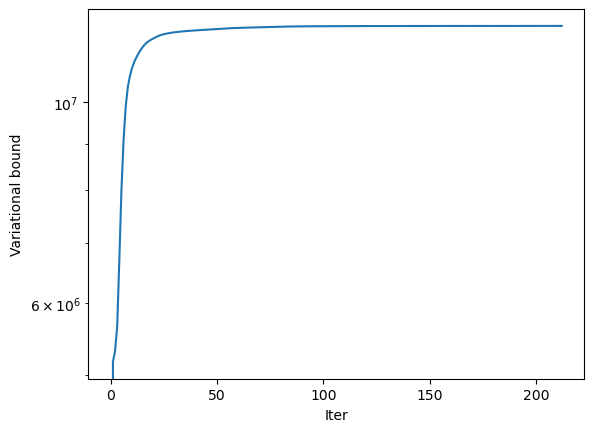

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([280, 280, 20, 12, 3]), device='cuda',
     n_components=50)

In [5]:
n_components = 50
max_iter = 500
tol = 1e-6
verbose = True

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=verbose, tol=tol)

# Mask with last mode completely masked

Change is small enough, early break:  35%|███▌      | 176/500 [06:16<11:33,  2.14s/it]                         


Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-2745577702.834813, 5301698.416721384, 5416236.519446858, 5769965.514380863, 6754896.915375147, 8114778.6303700525, 9139009.532582272, 9796513.619070476, 10262549.426748276, 10616557.97110971, 10876370.315381078, 11074781.25329366, 11233371.322008159, 11359326.498575402, 11456532.213323532, 11535218.85814202, 11601218.222900476, 11655780.402708666, 11700326.268107977, 11737106.084892642, 11768476.558254935, 11796677.524128787, 11822747.371554295, 11847145.346144749, 11869030.041504625, 11887987.845865324, 11904774.110496629, 11919886.41014574, 11933619.964487238, 11946210.94446704, 11957885.57039946, 11968884.744092647, 11979490.120819867, 11989918.060958946, 12000255.100222437, 12010290.930074906, 12019672.186213374, 12028166.337040063, 12035610.733108133, 12041985.122819431, 12047429.816259285, 12052008.07375255, 12055818.604172727, 12059015.013270471, 12061762.020221174, 12064156.79772158

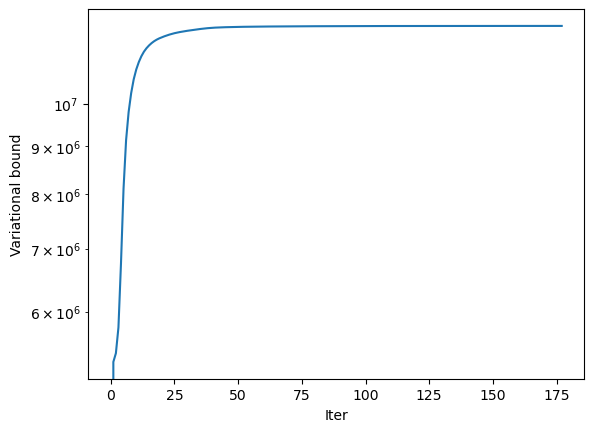

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([280, 280, 20, 12, 3]), device='cuda',
     n_components=50)

In [6]:
mask = np.ones(data.shape)
# april of GDELT is set to missing
mask[:, :, :, 3, :] = 0

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 0
mask = torch.tensor(mask.astype(np.int64), dtype=torch.float64, device=device)

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=verbose, tol=tol)

# Mask with the 1st and 3rd indices masked

Change is small enough, early break:  40%|███▉      | 199/500 [15:12<23:00,  4.58s/it]                               


Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-2759250965.024071, 5738005.699304538, 6159811.919548552, 6738820.837586331, 7816417.244168902, 8950570.473125203, 10004685.45285923, 10868065.376742257, 11458500.007807313, 11860679.53947883, 12137580.183019808, 12341700.357003786, 12501473.194405869, 12629706.305952191, 12735364.470386399, 12824546.605204703, 12900368.617725283, 12966069.487068124, 13023217.976639388, 13074972.191241864, 13120405.280855315, 13155758.101404391, 13182613.599216357, 13203463.775870577, 13220402.775859237, 13234779.25806196, 13247346.298719453, 13258621.592019448, 13268829.802155362, 13278147.483824069, 13286789.36442242, 13294903.190839823, 13302583.983235685, 13309853.577180112, 13316556.280550802, 13322545.270434035, 13327857.048911847, 13332627.078913033, 13337002.2567395, 13341065.889579255, 13344851.54718991, 13348399.176759012, 13351764.93049244, 13355016.53808648, 13358222.327787107, 13361410.483196482

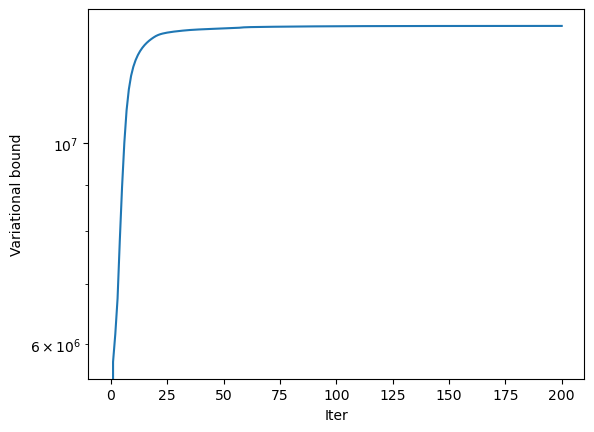

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([280, 280, 20, 12, 3]), device='cuda',
     n_components=50)

In [7]:
mask = np.ones(data.shape)
# april is set to missing
mask[:, :, :, 3, [0, 2]] = 0

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 0
mask = torch.tensor(mask.astype(np.int64), dtype=torch.float64, device=device)

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=verbose, tol=tol)

# Mask with only diagonals masked

Change is small enough, early break:  47%|████▋     | 234/500 [12:35<14:18,  3.23s/it]                         

Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-2956127198.1282434, 5939246.956432176, 6053125.262090744, 6458567.806716369, 7474960.446935107, 8776837.539149964, 10109953.957551345, 11132042.35295985, 11757044.988237808, 12141923.695526976, 12384019.531671228, 12548131.562742863, 12667661.516112745, 12757859.724806366, 12827868.860101713, 12883832.812679576, 12929507.543643044, 12966403.819904868, 12996828.68124129, 13023153.08601852, 13046569.853550998, 13067429.480835881, 13086081.575562533, 13102816.910813367, 13117903.975234164, 13131566.36016113, 13144166.224389033, 13155967.66165555, 13166987.772177057, 13177135.661450755, 13186437.43488265, 13194964.312757174, 13202805.960303886, 13210036.769782357, 13216680.873377133, 13222686.974906925, 13227993.505522916, 13232632.490363281, 13236735.774614133, 13240709.497573802, 13244312.312341308, 13247472.287496194, 13250423.571678719, 13253271.569691852, 13256155.90422706, 13259358.422407

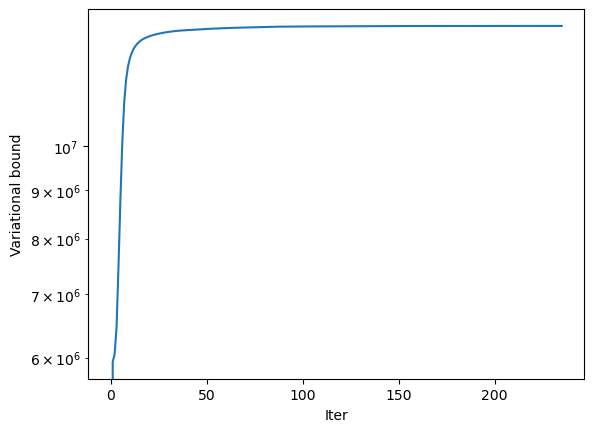

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([280, 280, 20, 12, 3]), device='cuda',
     n_components=50)

In [8]:
mask = np.ones(data.shape)

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 0
mask = torch.tensor(mask.astype(np.int64), dtype=torch.float64, device=device)

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=verbose, tol=tol)

# No mask

Change is small enough, early break:  35%|███▍      | 173/500 [06:28<12:14,  2.25s/it]                         

Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-2963299654.600768, 8318504.883143383, 8522452.527009863, 9292129.423917979, 11105100.115908237, 13426102.396349518, 15314171.988691332, 16600756.26987382, 17341508.13315627, 17760511.13400593, 18024266.583438072, 18208010.621821232, 18343622.036780447, 18445414.592575386, 18527114.53311139, 18596419.899159987, 18656334.802829478, 18708817.706599988, 18752914.795199662, 18788373.681459412, 18817444.1879878, 18842023.510845598, 18862723.241889633, 18880154.804688774, 18895143.704396002, 18907889.96421472, 18918773.044530433, 18928202.43573018, 18936537.62553886, 18944079.717750765, 18950933.285844114, 18957035.320921555, 18962493.49516654, 18967510.885436665, 18972238.058500443, 18976775.889024798, 18981203.947580725, 18985571.0970054, 18989892.93862476, 18994177.562937327, 18998441.507559754, 19002676.360351343, 19006842.111741878, 19010900.928883955, 19014857.029648386, 19018625.972462557, 

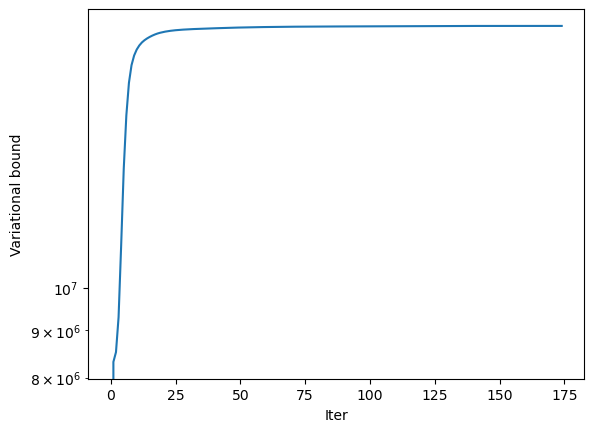

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([280, 280, 20, 12, 3]), device='cuda',
     n_components=50)

In [9]:
BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = None, max_iter = max_iter, verbose=verbose, tol=tol)

In [10]:
with torch.no_grad():
    # torch.cuda.synchronize()
    b1 = BPTF_model._elbo(data, mask)
    torch.cuda.synchronize()
    b2 = BPTF_model._elbo(data, mask)
print((b2 - b1) * 1e8)               # absolute change in “ULPs”

tensor(0., device='cuda:0')
